
<h1>Assignment 8: Applying PCA on the Diabetes and MNIST Dataset</h1>
    <p>This exercise will guide you through the process of applying Principal Component Analysis (PCA) to the Diabetes dataset, and observing its impact on the performance of a linear regression model using image data (MNIST).</p>
    <h2>Objectives:</h2>
    <ul>
        <li>Understand the process of standardizing dataset features.</li>
        <li>Learn to apply PCA for dimensionality reduction.</li>
        <li>Compare the performance of linear and logistic regression models with and without PCA.</li>
        <li>Visualize the explained variance ratio to understand the contribution of each principal component.</li>
        <li>MNIST: Visualize original MNIST images.</li>
        <li>MNIST: Visualize the reconstruction of images after PCA to observe the effect of dimensionality reduction.</li>
        <li>MNIST: Visualize the principal components as images.</li>
    </ul>
    <h2>Task 1: PCA and Linear Regression for Diabetes Dataset</h2>
    <ol>
        <li>Load the Diabetes dataset using <code>load_diabetes()</code> function from <code>sklearn.datasets</code>.</li>
        <li>Standardize the features of the dataset using <code>StandardScaler</code> from <code>sklearn.preprocessing</code>.</li>
        <li>Split the data into training and testing sets using <code>train_test_split()</code> function with a test size of 20% and a random state of 42.</li>
        <li>Apply PCA on the training data to reduce the dimensions while retaining 95% of the variance. Use <code>PCA</code> from <code>sklearn.decomposition</code> and fit it on the training set. Then, transform both the training and testing sets based on this fit.</li>
        <li>Train a linear regression model using the PCA-transformed training data. Use <code>LinearRegression</code> from <code>sklearn.linear_model</code>.</li>
        <li>Predict the target values for the PCA-transformed testing set and calculate the Mean Squared Error (MSE) using <code>mean_squared_error()</code> from <code>sklearn.metrics</code>.</li>
        <li>Repeat steps 5 and 6 without applying PCA to compare performance.</li>
        <li>Visualize the explained variance ratio for each principal component using <code>matplotlib.pyplot</code>.</li>
        <li>Based on the explained variance ratio choose an appropriate variance reduction.</li>
    </ol>

PCA retained components: 8
MSE with PCA: 2884.004945748083
MSE without PCA: 2900.1936284934827


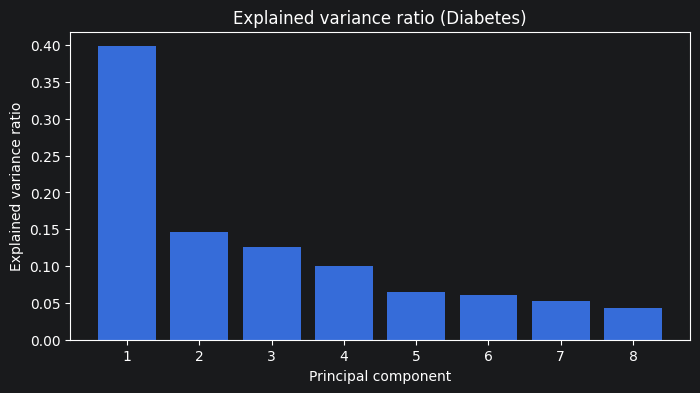

Cumulative explained variance: [0.39839796 0.54537129 0.67089845 0.77054101 0.8355516  0.89572815
 0.94807557 0.9915167 ]


In [1]:
# Task 1: PCA and Linear Regression for Diabetes dataset
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Load and standardize
X, y = load_diabetes(return_X_y=True)
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(Xs, y, test_size=0.2, random_state=42)

# Apply PCA to retain 95% variance
pca = PCA(n_components=0.95, svd_solver='full')
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Train linear regression on PCA-transformed data
lr = LinearRegression()
lr.fit(X_train_pca, y_train)
y_pred = lr.predict(X_test_pca)
mse_pca = mean_squared_error(y_test, y_pred)

# Train linear regression WITHOUT PCA for comparison
lr2 = LinearRegression()
lr2.fit(X_train, y_train)
y_pred2 = lr2.predict(X_test)
mse_no_pca = mean_squared_error(y_test, y_pred2)

print('PCA retained components:', pca.n_components_)
print('MSE with PCA:', mse_pca)
print('MSE without PCA:', mse_no_pca)

# Plot explained variance ratio
plt.figure(figsize=(8,4))
plt.bar(np.arange(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_)
plt.xlabel('Principal component')
plt.ylabel('Explained variance ratio')
plt.title('Explained variance ratio (Diabetes)')
plt.show()

# Print cumulative explained variance to help choose dimensionality
print('Cumulative explained variance:', np.cumsum(pca.explained_variance_ratio_))


<h2>Task 2: PCA and Classification on the MNIST Dataset</h2>
    <ol>
        <li>Load and normalize the MNIST dataset.</li>
        <li>Visualize the first few images from the MNIST dataset.</li>
        <li>Split the dataset into training and testing sets.</li>
        <li>Apply PCA to the training data to reduce its dimensionality, aiming to retain 80% of the variance. Transform both the training and testing sets based on the PCA fit.</li>
        <li>Apply the inverse transform to the PCA-reduced training data to reconstruct the images and visualize the first few original and reconstructed images.</li>
        <li>Visualize the first few principal components as images and the explained variance ratio for each component.</li>
        <li>Train a logistic regression classifier on the PCA-reduced training dataset, predict on the testing set, and calculate the classification accuracy. Visualize the confusion matrix.</li>
        <li>Repeat the training and evaluation of the logistic regression classifier on the original dataset (without PCA) for comparison. Visualize the confusion matrix.</li>
    </ol>


MNIST loaded via fetch_openml.


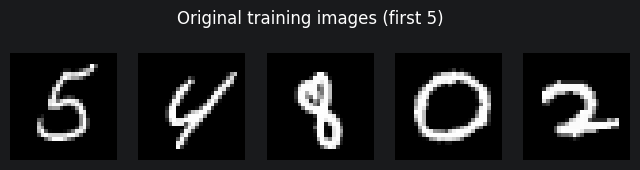

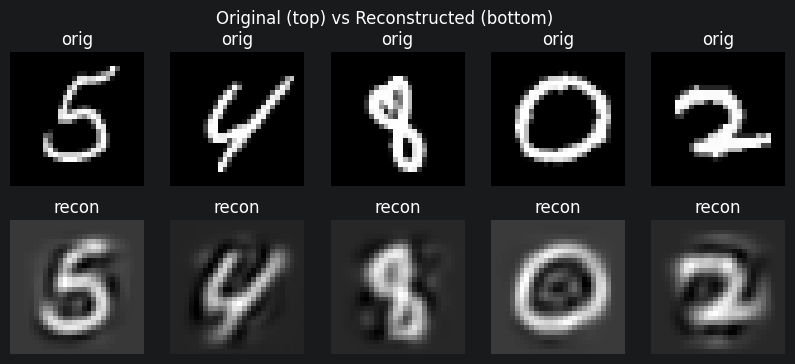

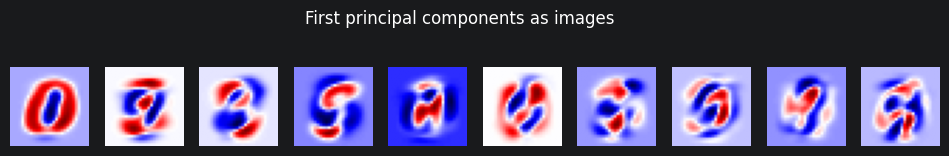

In [ ]:
# Task 2: PCA and Classification on MNIST (or digits fallback)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

try:
    from sklearn.datasets import fetch_openml
    mnist = fetch_openml('mnist_784', version=1, as_frame=False)
    X = mnist.data.astype(np.float32)
    y = mnist.target.astype(int)
    print('MNIST loaded via fetch_openml.')
except Exception:
    from sklearn.datasets import load_digits
    d = load_digits()
    X = d.data
    y = d.target
    print('fetch_openml failed, using load_digits as fallback.')

# Normalize
X = X.astype(np.float32)
X = X / np.maximum(X.max(), 1.0)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Image side (assumes square images)
image_side = int(np.sqrt(X.shape[1]))

# Show some original images
plt.figure(figsize=(8,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[i].reshape(image_side, image_side), cmap='gray')
    plt.axis('off')
plt.suptitle('Original training images (first 5)')
plt.show()

# PCA retain 80% variance
from sklearn.decomposition import PCA
pca2 = PCA(n_components=0.80, svd_solver='full')
X_train_pca = pca2.fit_transform(X_train)
X_test_pca = pca2.transform(X_test)

# Reconstruct some images
X_train_recon = pca2.inverse_transform(X_train_pca)
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(image_side, image_side), cmap='gray')
    plt.title('orig')
    plt.axis('off')
    plt.subplot(2,5,5+i+1)
    plt.imshow(X_train_recon[i].reshape(image_side, image_side), cmap='gray')
    plt.title('recon')
    plt.axis('off')
plt.suptitle('Original (top) vs Reconstructed (bottom)')
plt.show()

# Show first principal components as images
components = pca2.components_
n_show = min(10, components.shape[0])
plt.figure(figsize=(12,2))
for i in range(n_show):
    plt.subplot(1,n_show,i+1)
    plt.imshow(components[i].reshape(image_side, image_side), cmap='seismic')
    plt.axis('off')
plt.suptitle('First principal components as images')
plt.show()

# Logistic Regression on PCA features
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_pca, y_train)
y_pred = clf.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred)
cm_pca = confusion_matrix(y_test, y_pred)

# Logistic Regression on original features
clf2 = LogisticRegression(max_iter=1000)
clf2.fit(X_train, y_train)
y_pred2 = clf2.predict(X_test)
acc_no_pca = accuracy_score(y_test, y_pred2)
cm_no_pca = confusion_matrix(y_test, y_pred2)

print('--- Task 2 Results ---')
print('Components (80%):', pca2.n_components_)
print('Accuracy with PCA:', acc_pca)
print('Accuracy without PCA:', acc_no_pca)

# Confusion matrices
plt.figure(figsize=(6,5))
sns.heatmap(cm_pca, annot=True, fmt='d')
plt.title('Confusion matrix (with PCA)')
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(cm_no_pca, annot=True, fmt='d')
plt.title('Confusion matrix (without PCA)')
plt.show()
